LoanForest is a Streamlit web application that predicts the risk of loan default using a Random Forest machine learning model. Users interact with the app via feature sliders to input loan and applicant details, receiving an instant prediction of default risk.

**Loading Necessary Libraries**

In [1]:
# Utilities and data manipulation libraries
import joblib
import pandas as pd
import numpy as np
import os

# SHAP library for model explainability
import shap

# Data visualization libraries
import plotly
import seaborn as sns
from matplotlib import pyplot as plt
from optuna.visualization import plot_optimization_history, plot_param_importances

# Machine learning libraries
import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import TargetEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer

# Model evaluation libraries
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    f1_score,
    make_scorer
) 
from sklearn.inspection import permutation_importance

# Libraries for handling imbalance
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline

import matplotlib
matplotlib.use("TkAgg")

%matplotlib inline

c:\Users\chino\Documents\EuronProjects\LoanDefaultPredictor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Loading Dataset**

In [2]:
# Loading the dataset
df = pd.read_csv("../data/loan_data.csv")

In [3]:
# Displaying the first few rows of the dataset
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [4]:
# Displays the columns names
df.columns

Index(['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc',
       'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
       'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid'],
      dtype='str')

**Data Preview and Cleaning**

In [5]:
# Data Overview and Cleaning Function
def data_preview(data):
    """
    Provides a quick overview of the dataframe including:
      shape, 
      info, 
      description, 
      missing values
      duplicates.
    Args:
        df: The input dataframe.
    Returns:
        None
    """
    print("Dataframe Shape:", data.shape)
    print("\nDataframe Info:")
    print(data.info())
    print("\nDataframe Description:")
    print(data.describe())
    print("\nMissing Values:")
    print(data.isnull().sum())
    print("\nNumber of Duplicates:") 
    print(data.duplicated().sum())
    print("\nCount of Values Not Fully Paid:")
    print(data['not.fully.paid'].value_counts())
    

# Calling the data preview function
data_preview(df)

Dataframe Shape: (9578, 14)

Dataframe Info:
<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), str(1)
memory usage: 1.0 MB
None

Dataframe Description:
    

**Exploratory Data Analysis (EDA)**

In [6]:
# Data Visualization Function
def data_visualization(data):
    """
    Visualizes the relationships between some key features and the target variable 
    'not.fully.paid' using various plots.
    Args:
        data: The input dataframe.
    Returns:
        None
    """
    # Set the style of the plots
    sns.set_style("whitegrid")
    # Setting up the figure and axes for multiple plots
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(29, 15))

    # Flatten the axes array for easy indexing
    axes = axes.flatten()
    
    # Plot the distribution of the target variable
    sns.countplot(x='not.fully.paid', 
                  data=data, 
                  ax=axes[0])
    axes[0].set_title('Distribution of Not Fully Paid')
    axes[0].set_xlabel('Not Fully Paid (0 = No, 1 = Yes)')
    axes[0].set_ylabel('Count')

    # Plot the relationship between 'fico' scores and 'not.fully.paid'
    sns.boxplot(x='not.fully.paid', 
                y='fico', 
                data=data, 
                ax=axes[1])
    axes[1].set_title('FICO Scores by Not Fully Paid Status')
    axes[1].set_xlabel('Not Fully Paid (0 = No, 1 = Yes)')
    axes[1].set_ylabel('FICO Score')

    # Plot the relationship between 'fico' scores and 'int.rate'
    sns.scatterplot(x='fico', 
                    y='int.rate', 
                    data=data, 
                    ax=axes[2],
                    alpha=0.5)
    axes[2].set_title('FICO Scores vs Interest Rate')
    axes[2].set_xlabel('FICO Score')
    axes[2].set_ylabel('Interest Rate')

    # Plot the relationship between 'purpose' and 'not.fully.paid'
    sns.countplot(x='purpose', 
                  hue='not.fully.paid', 
                  data=data,
                  ax=axes[3], 
                  palette='Set1')
    axes[3].set_title('Purpose vs Not Fully Paid')
    axes[3].set_xlabel('Purpose of Loan')
    axes[3].set_ylabel('Count')
    axes[3].legend(title='Not Fully Paid')

    # Computing the correlation matrix and visualizing it with a heatmap.
    corr = data.select_dtypes(include=['number']).corr()
    sns.heatmap(corr, 
                annot=True, 
                cmap='coolwarm', 
                linewidths=0.5, 
                ax=axes[4])
    axes[4].set_title('Correlation Heatmap')
    fig.savefig('./images/data_visualization.png')

    # Hide the last subplot (empty)
    axes[5].set_visible(False)

    fig.tight_layout()
    plt.show()  

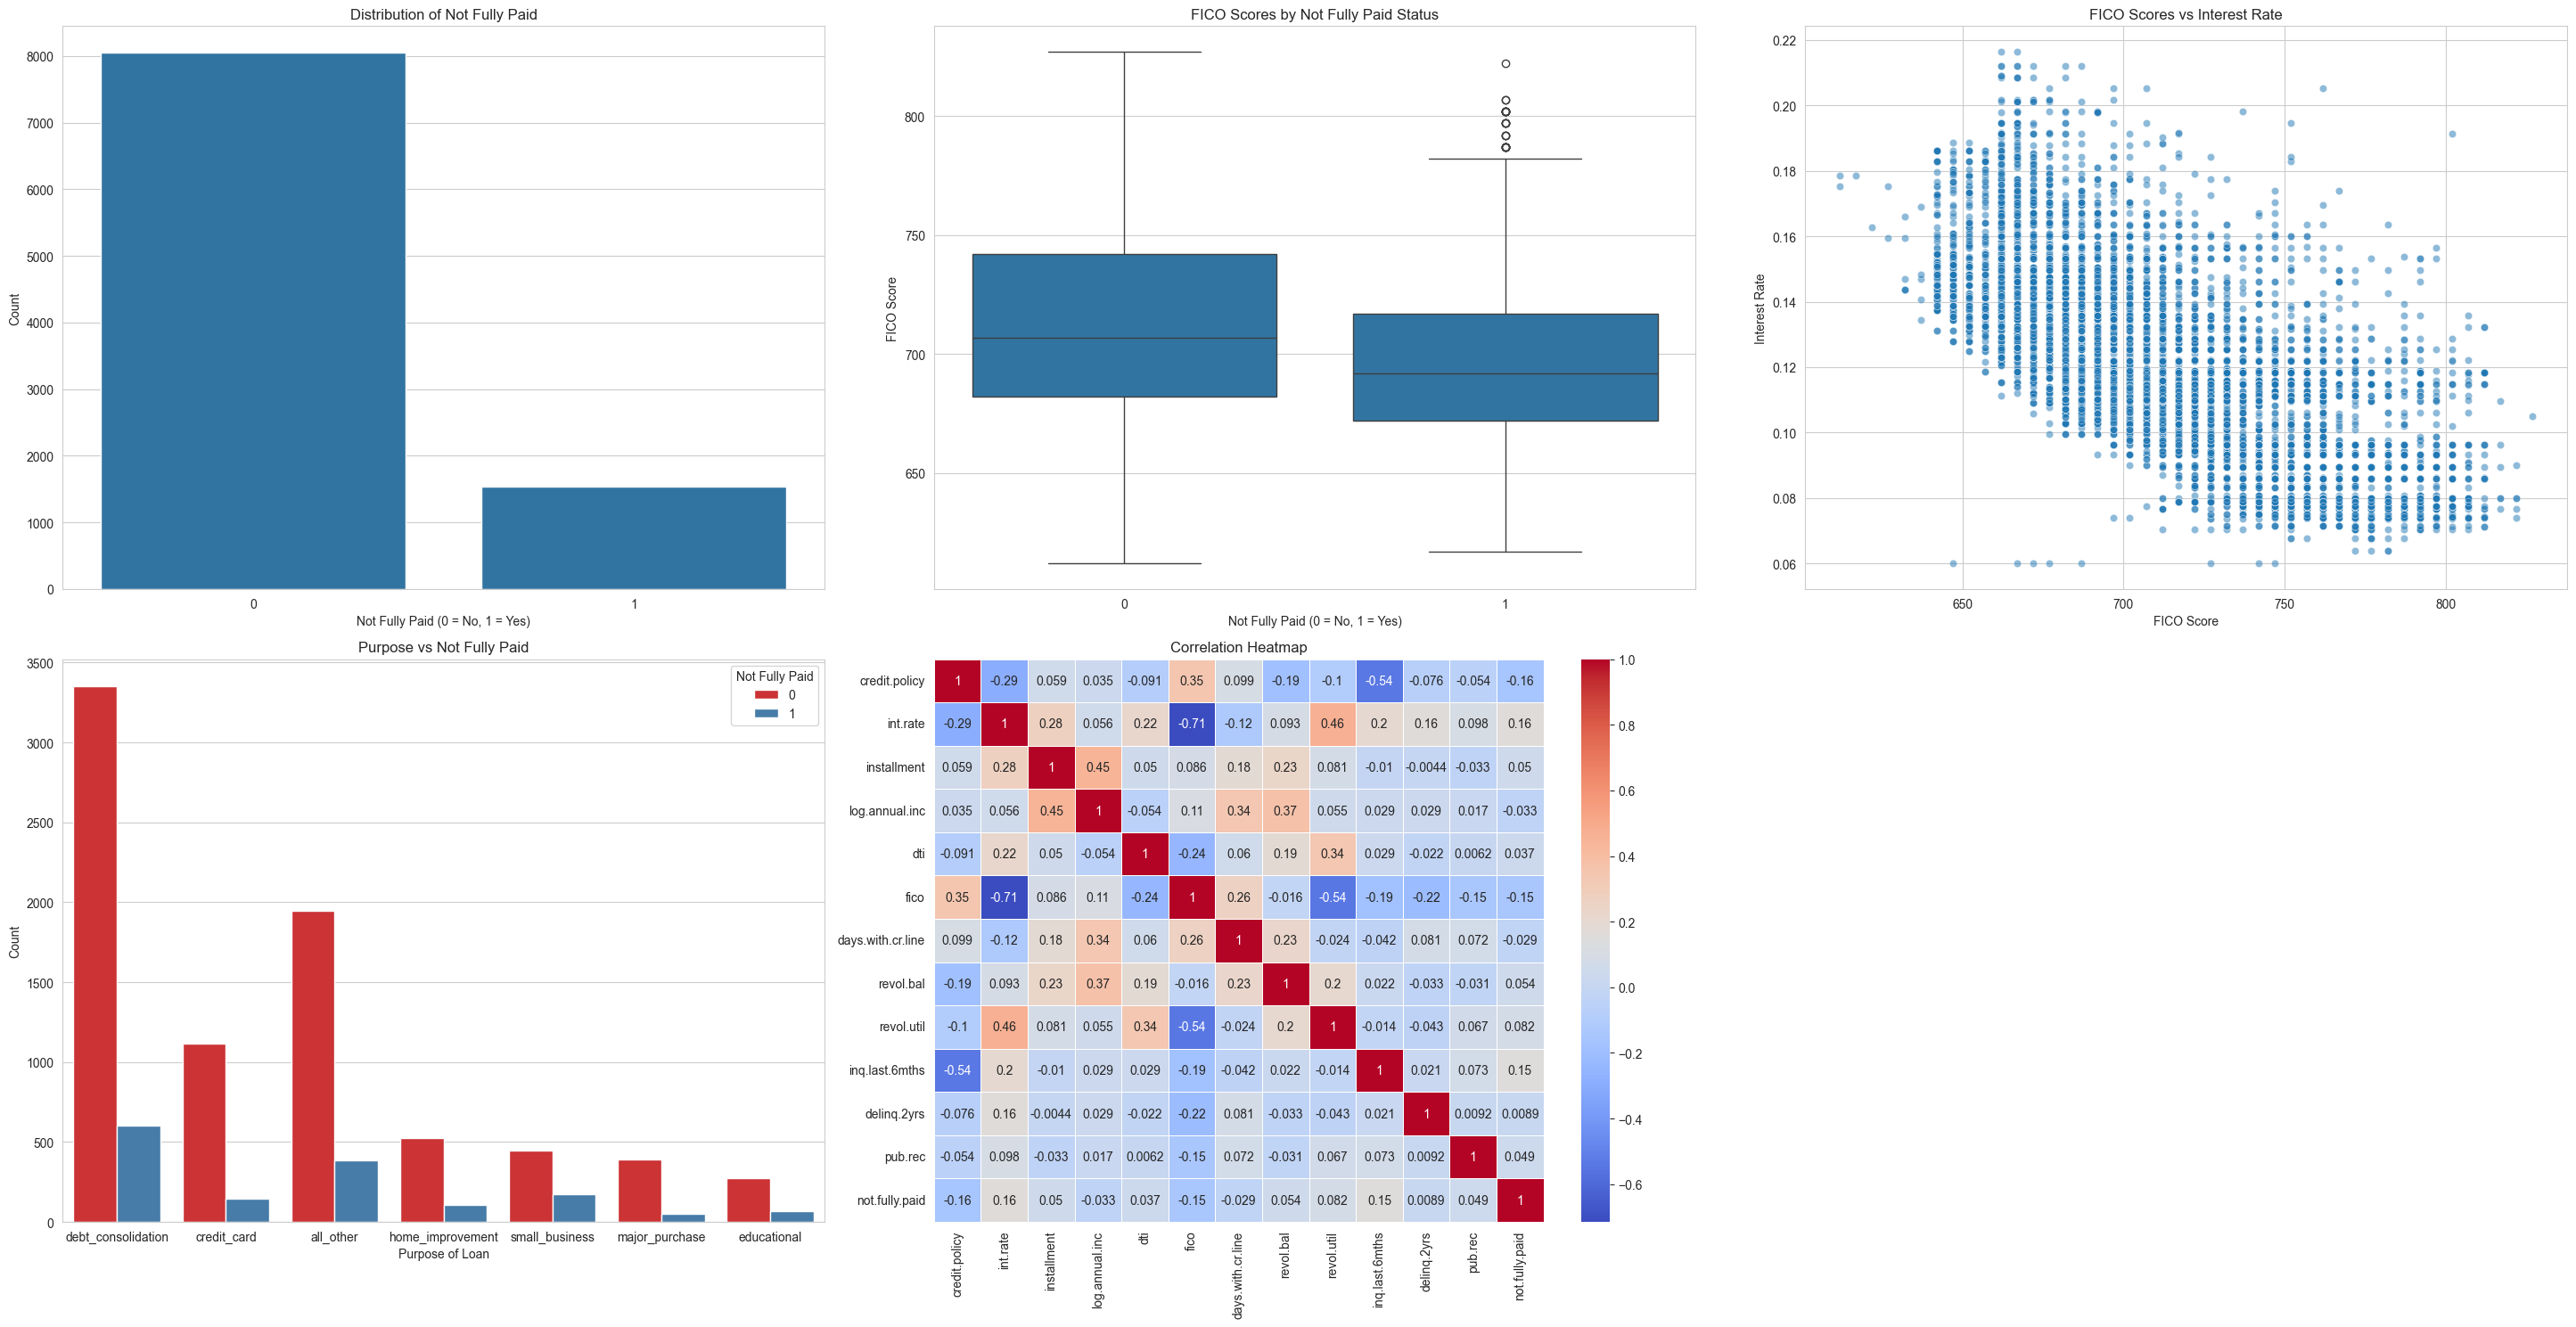

In [7]:
# Calling the data visualization function.
data_visualization(df)

**Feature Engineering**

In [8]:
# Drop irrelevant columns
df.drop(['purpose'], axis=1, inplace=True)

In [9]:
# Global variable for feature importance elsewhere in the notebook
X = df.drop(columns='not.fully.paid')
y = df['not.fully.paid']

# Function to split data into train/test sets, encode categorical variables, and scale features
def split_data(X, y, test_size=0.2, random_state=42):
    """
    This function splits the dataframe into training and testing sets.
    1. Convert categorical variables into numeric using OrdinalEncoder.
    2. Assign the independent variable to X and the dependent variable to y.
    3. Splits the dataset into training and testing sets using an 80-20 ratio.
    4. Normalize the large value using StandardScaler
    
    Args:
        X (pd.DataFrame): The input dataframe to be split.
        y (pd.Series): The target variable.
        test_size (float): The proportion of the dataset to include in the test split.
        random_state (int): The seed used by the random number generator.
    Returns:
        X_train, X_test, y_train, y_test: Split datasets.
    """
    # Avoid modifying the original X dataframe
    X = X.copy()

    try:
        # Split the dataset into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, 
                                                            random_state=random_state, 
                                                            stratify=y)

    except Exception as e:
        print(f"Error during data splitting: {e}")
        raise e
    
    # Select categorical columns and apply Ordinal Encoding
    categorical_cols = X_train.select_dtypes(include='str').columns

    # Check if there are any categorical columns before applying encoding
    if not categorical_cols.empty:
        preprocessor = ColumnTransformer(
            transformers=[
                ('encoder', TargetEncoder(random_state=random_state), categorical_cols)
            ],
            remainder='passthrough'
        )
    else:
        preprocessor = None

    try:
        if preprocessor is not None:
            # Fit the preprocessor on the training data and transform test.
            X_train_transform = preprocessor.fit_transform(X_train, y_train)
            X_test_transform = preprocessor.transform(X_test)

            # Get the new column names after encoding
            col_names = preprocessor.get_feature_names_out()
            X_train_processed = pd.DataFrame(X_train_transform, 
                                                columns=col_names, 
                                                index=X_train.index)
            X_test_processed = pd.DataFrame(X_test_transform, 
                                            columns=col_names, 
                                            index=X_test.index)
        else:
            X_train_processed = X_train
            X_test_processed = X_test

    except Exception as e:
        print(f"Error during preprocessing: {e}")
        raise e
        

    # Print the shapes of the split datasets
    print(
        f"X_train: {X_train_processed.shape}, X_test: {X_test_processed.shape}," 
        f"y_train: {y_train.shape}, y_test: {y_test.shape}"
        )
    
    return X_train_processed, X_test_processed, y_train, y_test, preprocessor

In [10]:
# Apply the split_data function to the preprocessed dataframe
X_train_processed, X_test_processed, y_train, y_test, preprocessor = split_data(X, y)

X_train: (7662, 12), X_test: (1916, 12),y_train: (7662,), y_test: (1916,)


**Model Development.**

In [ ]:
def best_hyperparameters(trial):
    """
    This function defines the hyperparameters for the RandomForestClassifier that will be optimized using Optuna.
    Args:
        trial: An Optuna trial object that suggests values for the hyperparameters.
    Returns:
        A dictionary of hyperparameters for the RandomForestClassifier.
    """
    rf_params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 5, 25),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'class_weight': trial.suggest_categorical('rf_class_weight', ['balanced', 'balanced_subsample'])
    }

    # Training Data using randomforestclassifier
    rf_pipeline = Pipeline([
        ('smoteenn', SMOTEENN(random_state=42)),
        ('rf', RandomForestClassifier(**rf_params, random_state=42))
    ])

    # Cross-validation to evaluate the model's performance with the current hyperparameters
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(rf_pipeline, X, y, cv=cv, scoring=scorer, n_jobs=-1)
    return scores.mean()


# Create an Optuna study and optimize the hyperparameters
study = optuna.create_study(direction='maximize')
study.optimize(best_hyperparameters, n_trials=25)

# Get the best hyperparameters
best_params = study.best_params
print("Best Hyperparameters:", best_params)

[I 2026-06-18 22:10:11,229] A new study created in memory with name: no-name-90806021-eb2d-4108-8ea9-6f53b3096e6b
[I 2026-06-18 22:10:28,715] Trial 0 finished with value: 0.5503879450505951 and parameters: {'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 3, 'rf_class_weight': 'balanced'}. Best is trial 0 with value: 0.5503879450505951.
[I 2026-06-18 22:10:41,533] Trial 1 finished with value: 0.5577122901798979 and parameters: {'n_estimators': 300, 'max_depth': 5, 'min_samples_leaf': 1, 'rf_class_weight': 'balanced'}. Best is trial 1 with value: 0.5577122901798979.
[I 2026-06-18 22:10:55,677] Trial 2 finished with value: 0.553617246448303 and parameters: {'n_estimators': 150, 'max_depth': 18, 'min_samples_leaf': 3, 'rf_class_weight': 'balanced'}. Best is trial 1 with value: 0.5577122901798979.
[I 2026-06-18 22:11:08,907] Trial 3 finished with value: 0.5567184885366376 and parameters: {'n_estimators': 150, 'max_depth': 10, 'min_samples_leaf': 2, 'rf_class_weight': 'balanced_subs

In [ ]:
# Plot optimization history
plot_optimization_history(study)

# Plot parameter importances
plot_param_importances(study)

plt.show()

In [ ]:
# Predicting the test set results
probabilities = rf_pipeline.predict_proba(X_test_processed)[:, 1]
y_pred = (probabilities >= 0.40).astype(int)

In [ ]:
# Function to display classification report and confusion matrix
from numpy.random import f


def model_result(y_true, y_hat):
    """
    Displays the confusion matrix and classification report for the given true and predicted labels.
    Args:
        y_true: The true labels.
        y_hat: The predicted labels.
    Return:
        classification_report: A text summary of the precision, recall, F1 score, and support for each class.
        roc_auc_score: The area under the receiver operating characteristic curve.
        balanced_accuracy_score: The balanced accuracy score.
    """
    # Compute the confusion matrix.
    cm = confusion_matrix(y_true, y_hat)

    # Visualize using heatmap.
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, annot=True, cmap='coolwarm', linewidths=0.5,
                xticklabels=['Non-Default', 'Default'],
                yticklabels=['Non-Default', 'Default'])
    
    plt.title('Confusion Matrix')
    plt.xlabel("Predicted Labels.")
    plt.ylabel("Actual Labels.")
    plt.tight_layout()
    plt.savefig('./images/confusion_matrix.png')
    plt.show()

    class_report = classification_report(y_true, y_hat)
    roc_auc = roc_auc_score(y_true, y_hat)
    balanced_acc = balanced_accuracy_score(y_true, y_hat)

    print(f"Classification Report:\n{class_report}")
    print(f"ROC AUC: {roc_auc}")
    print(f"Balanced Accuracy: {balanced_acc}")


In [ ]:
# Initialize the model evaluation function
model_result(y_test, y_pred)

In [ ]:
# Function to explain a single applicant's prediction using SHAP values
def explain_single_applicant(model, X_explain, row_index, columns_names,
                              top_n=10, save_path=None):
    """
    Generates a per-applicant SHAP explanation with waterfall plot.

    Args:
        model: The trained model (RandomForestClassifier or Pipeline).
        X_explain: The DataFrame containing the features for explanation.
        row_index: The index of the applicant in X_explain to explain.
        columns_names: List of feature names corresponding to the columns in X_explain.
        top_n: The number of top features to display in the waterfall plot.
        save_path: Optional path to save the waterfall plot. If None, the plot will be displayed instead of saved.
    Returns:
        explanation_df: DataFrame containing feature names, values, and SHAP contributions.
        base_value: The baseline prediction value (average predicted default probability).
        predicted_value: The predicted value for the specific applicant.
    """
    # Extract the tree model whether it's bare or inside a Pipeline
    if hasattr(model, 'feature_importances_'):
        tree_model = model
    elif hasattr(model, 'named_steps') and 'rf' in model.named_steps:
        tree_model = model.named_steps['rf']
    else:
        raise ValueError("Model does not expose a tree-based estimator named 'rf'.")

    # Keep row as a DataFrame to preserve structure
    row = X_explain.iloc[[row_index]]

    try:
        # Use check_additivity=False if you encounter slight floating-point mismatches
        explainer = shap.TreeExplainer(tree_model, model_output="probability", data=X_explain)
        explanation = explainer(row)
    except Exception as e:
        print(f"Error occurred while calculating SHAP values for this applicant: {e}")
        return None, None, None

    # Handle multi-class / binary classification output shapes safely
    # If explanation has 3 dimensions (row, feature, class), isolate class 1 (default)
    if len(explanation.shape) == 3:
        exp_individual = explanation[0, :, 1]
    else:
        exp_individual = explanation[0]

    # Explicitly assign feature names to ensure alignment
    exp_individual.feature_names = list(columns_names)

    base_value = exp_individual.base_values
    contributions = exp_individual.values
    predicted_value = base_value + contributions.sum()

    # Create the summary DataFrame
    explanation_df = pd.DataFrame({
        'Feature Name': columns_names,
        'Feature Value': row.iloc[0].values,
        'SHAP Contribution': contributions
    })
    explanation_df['Abs Contribution'] = explanation_df['SHAP Contribution'].abs()
    explanation_df = explanation_df.sort_values(by='Abs Contribution', ascending=False)
    explanation_df = explanation_df.drop(columns='Abs Contribution').reset_index(drop=True)

    # Waterfall plot generation
    try:
        plt.figure(figsize=(10, 6))
        shap.plots.waterfall(exp_individual, max_display=top_n, show=False)
        if save_path:
            plt.tight_layout()
            plt.savefig(save_path, dpi=80, bbox_inches='tight')
            plt.close()
            print(f"Waterfall plot saved to {save_path}")
        else:
            plt.show()
    except Exception as e:
        print(f"Error occurred while plotting waterfall: {e}")

    print(f"Baseline (average predicted default probability): {base_value:.3f}")
    print(f"This applicant's predicted default probability:   {predicted_value:.3f}")

    return explanation_df, base_value, predicted_value

In [ ]:
# Initialize the feature importance function
explanation_df, base_value, predicted_value = explain_single_applicant(
    model=rf_pipeline,
    X_explain=X_test_processed,
    row_index=0,
    columns_names=X.columns,
    top_n=10,
    save_path='./images/applicant_explanation.png'
)
print(explanation_df)

In [ ]:
def plot_local_and_global_shap(model, X_explain, row_index, columns_names, top_n=10):
    """
    Plots a single applicant's waterfall plot side-by-side with the 
    overall dataset beeswarm summary plot.
    """
    # 1. Extract the tree estimator
    if hasattr(model, 'feature_importances_'):
        tree_model = model
    elif hasattr(model, 'named_steps') and 'rf' in model.named_steps:
        tree_model = model.named_steps['rf']
    else:
        raise ValueError("Model does not expose a tree-based estimator named 'rf'.")

    # 2. Compute explanations for both the single row and the entire pool
    explainer = shap.TreeExplainer(tree_model, model_output="probability", data=X_explain)
    
    # Calculate for all records (for Beeswarm) and single record (for Waterfall)
    all_explanations = explainer(X_explain)
    single_explanation = all_explanations[[row_index]]

    # 3. Handle multi-class dimensions for Random Forest output shape
    if len(all_explanations.shape) == 3:
        global_exp = all_explanations[:, :, 1]
        local_exp = single_explanation[0, :, 1]
    else:
        global_exp = all_explanations
        local_exp = single_explanation[0]

    # Assign feature names to the explanation objects
    global_exp.feature_names = list(columns_names)
    local_exp.feature_names = list(columns_names)

    # 4. Initialize matplotlib figure side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(22, 9))

    # Render Waterfall Plot on the Left
    plt.sca(axes[0])
    axes[0].set_title(f"Local Explanation: Applicant Row {row_index}", fontsize=14, pad=20)
    shap.plots.waterfall(local_exp, max_display=top_n, show=False)

    # Render Beeswarm Plot on the Right
    plt.sca(axes[1])
    axes[1].set_title("Global Explanation: Overall Feature Impact", fontsize=14, pad=20)
    shap.plots.beeswarm(global_exp, max_display=top_n, show=False)

    plt.subplots_adjust(
        left=0.15, right=0.90, top=0.85, bottom=0.15, wspace=0.45
    )

    fig.savefig('./images/local_global_shap.png', dpi=80, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

In [ ]:
# Initialize the combined SHAP plotting function
plot_local_and_global_shap(
    model=rf_pipeline,
    X_explain=X_test_processed,
    row_index=0,
    columns_names=X.columns,
    top_n=10
)

In [ ]:
# Save the trained model to disk
def save_model(model, filename):
    """
    Saves the trained model to disk using joblib.
    Args:
        model: The trained model to be saved.
        filename: The name of the file where the model will be saved.
    Returns:
        None
    """
    try:
        # Check if the directory exists, if not, create it
        dir_path = os.path.dirname(filename)
        if dir_path and not os.path.exists(dir_path):
            os.makedirs(dir_path)
            print(f"Directory '{dir_path}' created.")

        # Save the model to disk
        joblib.dump(model, filename)
        print(f"Model successfully saved to {filename}")

    except FileNotFoundError as e:
        print(f"Error: File not found when saving model: {e}")

    except PermissionError as e:
        print(f"Error: Permission denied when saving model: {e}")

    except Exception as e:
        print(f"An unexpected error occurred while saving the model: {e}")

In [ ]:
# Save the trained model to disk
save_model(rf_pipeline, './src/random_forest_model.pkl')

In [ ]:
# Function to load the model make predictions.
def load_and_predict(data):
    """
    Loads a trained model makes predictions on new data and inverse the transform label.
        1. Loads the trained model from disk.
        2. Makes predictions on the provided clean dataframe.
    Args:
        clean_df (pd.DataFrame): The preprocessed test dataframe.
    Returns:
        np.ndarray: The predicted labels in their original categorical form.
    """
    try:
        print("Loading the trained model...")
        # Load the trained model
        model = joblib.load('finalized_logistic_model.pkl')
        print("Model loaded successfully.")
        # Make predictions
        predictions = model.predict(data)
        print("Predictions made successfully.")

    except FileNotFoundError:
        print("Error: The model file was not found. Please ensure the model has been trained and saved correctly.")
        return None
    except KeyError as e:
        print(f"Prediction Error. Feature mismatch likely. {e}")
        return None
    except Exception as e:  
        print(f"An error occurred while loading the model: {e}")
        return None

    return predictions